In [2]:
# Analysing data set

import pandas as pd
import numpy as np
from scipy.interpolate import splev, splprep
import datashader as ds
import colorcet as cc
import matplotlib.pyplot as plt
import seaborn as sns
import openrouteservice as ors
from openrouteservice import directions
import time

In [15]:
df = pd.read_csv('Daily_Data_EV.csv')

In [ ]:
def prep_df(input_df):
    """
    Cleans original dataset from csv and keeps only relevant columns

    Parameters:
        - pandas dataframe

    Retunrs:
        - pandas dataframe (cleaned)
    """
    # split departure time into separate columns (2) for hours and minutes
    df_time_split = input_df['departure_time'].str.split(pat=':',expand=True).astype(int)

    # converting hour-minute format to float and joining back into one number
        # int value + 0. decimal value
    time_num_decimal =  df_time_split[0] + df_time_split[1]/60

    # put time decimal into pandas dataframe to join back with original
    df_time_decimal = pd.DataFrame({'time_decimal':time_num_decimal})
    df_time_int = pd.DataFrame({'time_int':df_time_split[0]})

    # joining new column with time decimal and int with main dataframe
    input_df = input_df.join(df_time_decimal).join(df_time_int)

    # separating dataset with only EV-#, Trip, Departure Time and Decimal Time
    clean_df = input_df[['EV Number', 'Trip', 'departure_time', 'time_decimal', 'time_int', 't_dist']]

    # splitting coordinate cells by ',' into separate latitude and longitude columns for source and destination
        # remember to convert into float
    source_df = input_df['source'].str.split(pat=",", expand=True).astype('float32')
    destination_df = input_df['destination'].str.split(pat=",", expand=True).astype('float32')

    # joining back into separate columns
    clean_df = pd.concat([clean_df, source_df, destination_df], axis=1)

    # renaming columns
    clean_df.columns = ['EV_Number', 'Trip','departure_time', 'time_decimal', 'time_int', 'distance', 'source_lat', 'source_lon', 'destination_lat', 'destination_lon']

    return clean_df


In [16]:
cleaned_df = prep_df(df)

Text(0.5, 0, 'Time (h)')

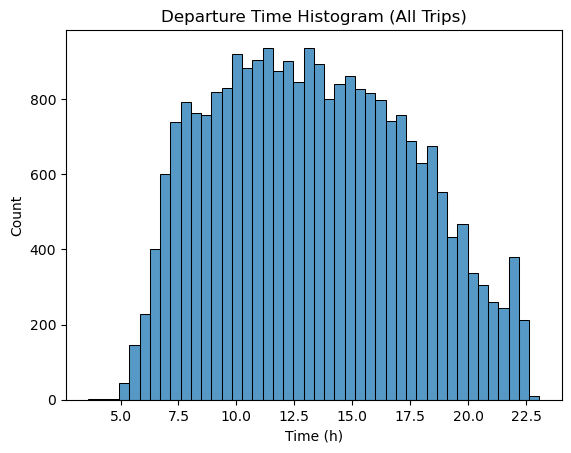

In [323]:
# histogram
sns.histplot(df["time_decimal"])
plt.title("Departure Time Histogram (All Trips)")
plt.xlabel("Time (h)")

Text(0.5, 1.0, 'Distance Traveled Histogram (All Trips)')

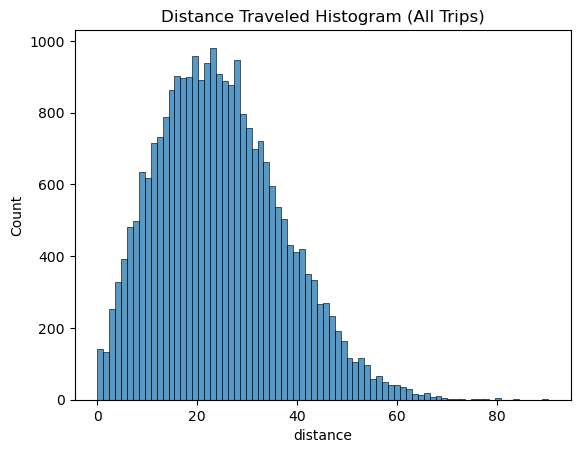

In [318]:
sns.histplot(cleaned_df["distance"])
plt.title("Distance Traveled Histogram (All Trips)")

In [ ]:
# Creating ors Client object to access API

# passing key, only for web API
# client = ors.Client(key='')

# Passing localhost port 8000 where Docker container is running
client = ors.Client(base_url='http://localhost:8080/ors')


In [ ]:
# get coordinates by time range
    # filter df by time range
    # get route for every motif / row / source-destin pair in df
    # append (coords, dept time) to coord list

# can pretty much ignore EV number

def get_points(df, time_range, err=False):
    """
    Calculates all routing points in df for time range (inclusive, exclusive]
        like 14:00 to 15:00 (up to 15:00, not included)

    Params:
        - df (pandas dataframe)
        - time_range (list size 2)
        - err=False (whether to show routing errors for routes that fail)

    Returns:
    """
    range_df = df[(df["time_int"] >= time_range[0]) & (df["time_int"] < time_range[1])]

    # 3d list - [lon, lat, time]
        # ex: [[34.52, -89.34, 6], [34.23, -89.43, 7], [34.56, -89.03, 9]]
    list_used = []

    for row in range_df.itertuples():
        depart_time = row.time_int
        ev_num = row.EV_Number
        coords_pair = [[row.source_lon, row.source_lat],[row.destination_lon, row.destination_lat]]

        # getting route from API, returns list with coordinate pair list
            # returns something similar to input (ex just above) except with more datapoints
        try:
            # api call to OpenRouteService 
            api_response = client.directions(coords_pair, profile="driving-car", format="geojson")
            # getting just coordinates from simulated path
            route_coord_list = api_response["features"][0]["geometry"]["coordinates"]

            ## Recalculating path so coordinates are evenly distributed along the path ##
            
            # converting to np array and splitting coords into lon and lat
                # note: np.array [:,0] comma - grabs all first elems of all elem in second array
                    # returns [-89.234, -89.2423, -89.5432, etc...]
                # different from expected [:][0] - from all el in first array grab first elem (happens to be arr)
                    # returns [-89.234, 36.543]
            lon = np.array(route_coord_list)[:,0]
            lat = np.array(route_coord_list)[:,1]

            # calculating b-spline along the points of returned path
            tck, u = splprep([lon, lat], s=0)

            # recalculating points along line with new parameter values evenly spaced out
            new_u = np.linspace(0, 1, 100) # 50 points generated, 50 good enough for ~all routes based on random testing
            
            # returns 50 new longitude and latitude coordinates along simulated path
            new_lon, new_lat = splev(new_u, tck)

            ##  --------------------------------------------------------------------- ##                                               

            # append coordinate list to master points list
                # new_lon and new_lat must be same size (should be)
            for i in range(len(new_lon)):
                list_used.append([new_lon[i], new_lat[i], depart_time])

        except ors.exceptions.ApiError as e:
            # catching errors for unreachable routes (mostly ev's that stopped inside airports etc., negligible)
            api_error_code = e.args[0]
            ors_error_code = e.args[1]["error"]["code"]
            ors_error_msg = e.args[1]["error"]["message"]
            if err:
                print("API Error: ", api_error_code)
                print("Error Code: ", ors_error_code)
                print("EV Number: ", ev_num)
                print("Message: ", ors_error_msg)
                print()
        except Exception as e:
            # catching splprep errors for odd datapoints with same source and destination (i.e., near 0 distance travelled)
            if err:
                print("Error: ", e)
                print("EV Number: ", ev_num)
                print()

        
    return list_used

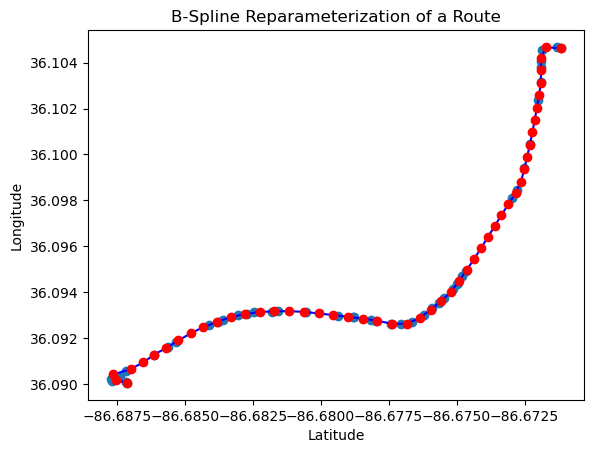

In [17]:
##### Reparameterization Test Sandbox ####

# df of EV-3 only for test
df_3 = cleaned_df[cleaned_df["EV_Number"]=="EV-3"]

# Selecting a single row in EV-3 df, to calculate route for one source-destination pair
value_arr = cleaned_df.iloc[14].tolist()
coords_pair_3 = [[float(value_arr[7]), float(value_arr[6])], [float(value_arr[9]), float(value_arr[8])]]

# simulating route for source-destination pair selected
api_response_3 = client.directions(coords_pair_3, profile="driving-car", format="geojson")
route_coord_list_3 = api_response_3["features"][0]["geometry"]["coordinates"]

# splitting into x and y 
x_unsorted = np.array(route_coord_list_3)[:,0]
y_unsorted = np.array(route_coord_list_3)[:,1]

# b-spline interpolation and reparameterization
new_t = np.linspace(0, 1, 50) # new parameterization
new_tck, u = splprep([x_unsorted, y_unsorted], s=0) # bspline interpolation
new_points = splev(new_t, new_tck) # bspline evaluation

# # Plot the original data and the smoothed spline
plt.title("B-Spline Reparameterization of a Route")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
# plt.bar(np.linspace(0,46,46), u)
plt.plot(x_unsorted, y_unsorted, 'o', label='Routing API Data')
plt.plot(new_points[0], new_points[1], 'b-', label='B-Spline Interpolation')
plt.plot(new_points[0], new_points[1], 'ro', label='Reparameterized Points')
# plt.legend()
# # plt.savefig('routes-generated/bspline/original-data.png')
plt.show()

In [ ]:
def generate_maps(start, end, read_path="./final_step_data_collection", save_path="./routes-generated/final"):
    """
    Generates maps from .csv files for each day and saves to some directory.

    Usage:
        generate_maps(1,31, read_path="./final_step_data_collection", save_path="./routes-generated/final")

        Reads all 30 .csv files in /final_set_data_collection directory and saves to /routes-generated/final

    Parameters:
        - start (start day)
        - end (end day)
        - read_path (directory where .csv files are located)
        - save_path

    Returns: Nothing
    """
    for day in range(start,end):
        # get data from csv file
        csv_path = "{}/day_{}.csv".format(read_path, day)
        
        # get df with relevant data
        day_df = prep_df(pd.read_csv(csv_path))

        # get points for day
        day_points = get_points(day_df, [0,24])

        # putting points back into dataframe for plotting with Datashader
        plotting_df = pd.DataFrame(day_points, columns=['lon', 'lat', 'time_int'])

        # setting the time_int column as category type (necessary for Datashade 3D aggregation by time dimension)
        plotting_df['time_int'] = plotting_df['time_int'].astype('category')

        # creating canvas for Datashader plotting
        ds_canvas = ds.Canvas(plot_width=500, plot_height=500)

        # making aggregate array
        agg = ds_canvas.points(plotting_df, 'lon', 'lat', ds.by('time_int', ds.count()))

        # getting list of categories to iterate through (should be <=24, for 24h)
        cat_to_shade = plotting_df["time_int"].cat.categories

        # plotting image for every category (hour) in dataset
        for cat in cat_to_shade:
            img_name = "day-{}-hour-{}".format(day, cat)
            img = ds.tf.set_background(ds.tf.shade(ds.tf.spread(agg.sel(time_int=cat), px=3), cmap=cc.fire), "black")
            ds.utils.export_image(img, filename=img_name, export_path=save_path)

In [ ]:
# creating all maps from local directory of .csv files, saving to other local directory
generate_maps(1,31, read_path="./final_step_data_collection", save_path="./routes-generated/final")